In [18]:
import ast
import re
from collections import defaultdict


def parse_line(line: str):
    result = {}

    # Regular expression to match key=value pairs, including arrays
    pattern = re.compile(r"(\w+)=((?:'[^']*')|(?:\d+\.?\d*%?)|(?:array\([^\)]*\)))")
    matches = pattern.findall(line)

    for key, value in matches:
        if key in ("rms_log_vals", "rms_vals"):
            # Remove 'array([' and '])' and parse the numbers inside
            array_str = value[len("array([") : -2]
            array_values = list(map(float, array_str.split(",")))
            suffixes = ["T", "E", "C", "M"]
            for suffix, val in zip(suffixes, array_values):
                result[f"{key}_{suffix}"] = val
        else:
            # Strip quotes if the value is a string
            if value.startswith("'") and value.endswith("'"):
                result[key] = value[1:-1]
            elif value.endswith("%"):
                # Remove '%' and convert to float
                result[key] = float(value[:-1])
            else:
                result[key] = ast.literal_eval(value)

    return result


def aggregate_dicts(dicts: list[dict]):
    aggregated = defaultdict(lambda: defaultdict(list))

    for d in dicts:
        key = (d["param"], d["noise_level"], d["n_pts"])

        for k, v in d.items():
            if k not in {"param", "noise_level", "n_pts"}:
                aggregated[key][k].append(v)
    
    return dict(aggregated)

import numpy as np
import matplotlib.pyplot as plt

def plot_heatmap_from_aggregated(aggregated, k):
    # Extract unique noise_levels and n_pts, sorted for consistent ordering
    param = list(aggregated.keys())[0][0]
    noise_levels = sorted(set(key[1] for key in aggregated.keys()))
    n_pts_values = sorted(set(key[2] for key in aggregated.keys()), reverse=True)

    # Initialize heatmap array
    heatmap = np.zeros((len(noise_levels), len(n_pts_values)))
    
    for i, nl in enumerate(noise_levels):
        for j, np_ in enumerate(n_pts_values):
            key = next(iter(k_ for k_ in aggregated if k_[1] == nl and k_[2] == np_), None)
            if key and k in aggregated[key]:
                values = aggregated[key][k]
                heatmap[i, j] = np.median(values)
            else:
                heatmap[i, j] = np.nan  # in case some combinations are missing

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    cax = ax.imshow(heatmap, cmap='viridis', aspect='auto')

    # Set labels
    ax.set_xticks(np.arange(len(n_pts_values)))
    ax.set_yticks(np.arange(len(noise_levels)))
    ax.set_xticklabels(n_pts_values)
    ax.set_yticklabels(noise_levels)
    ax.set_xlabel("n_pts")
    ax.set_ylabel("noise_level")
    ax.set_title(f"Median heatmap for '{k}', parameter {param}")

    # Annotate each cell
    for i in range(len(noise_levels)):
        for j in range(len(n_pts_values)):
            val = heatmap[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2e}", ha="center", va="center", color="white")

    fig.colorbar(cax, ax=ax, label='Median Value')
    plt.tight_layout()
    plt.show()    

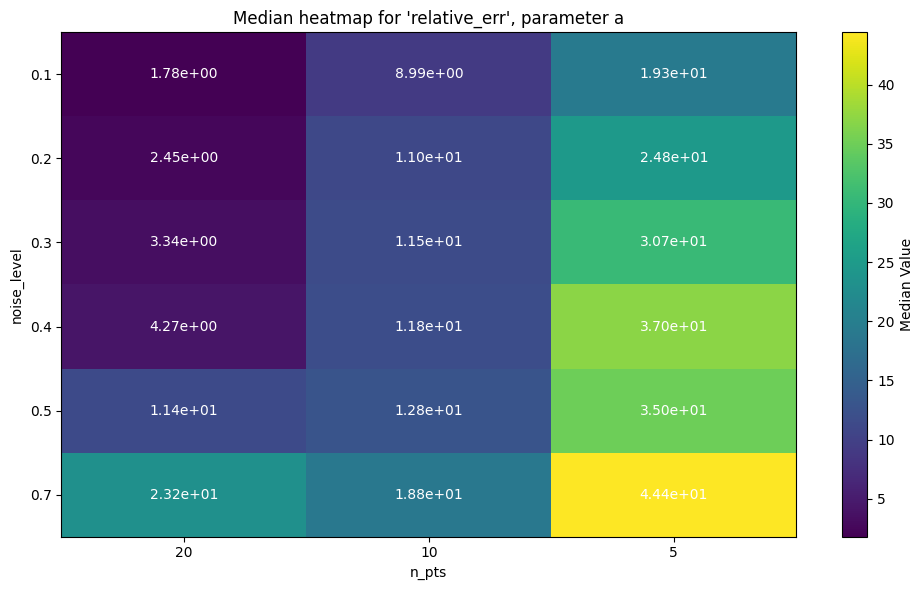

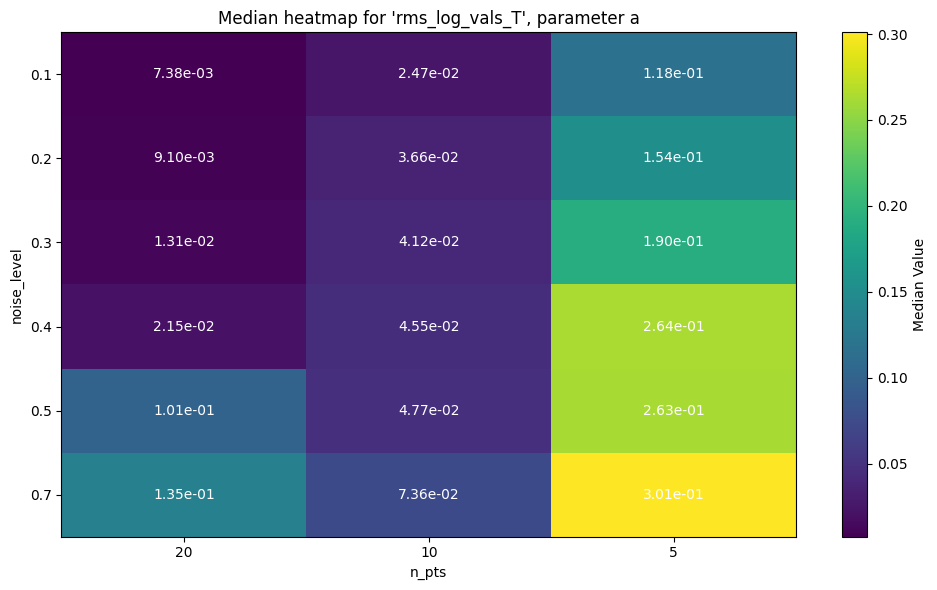

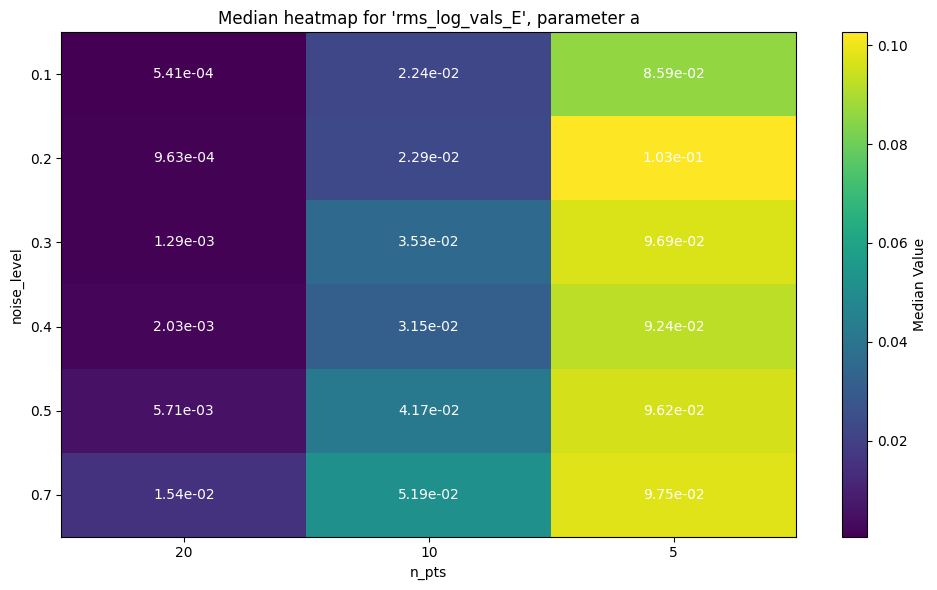

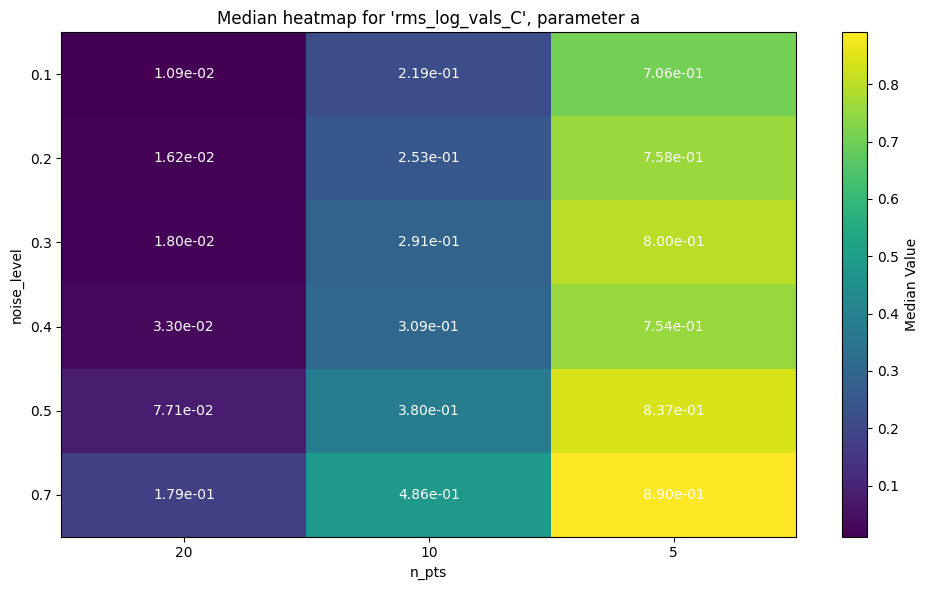

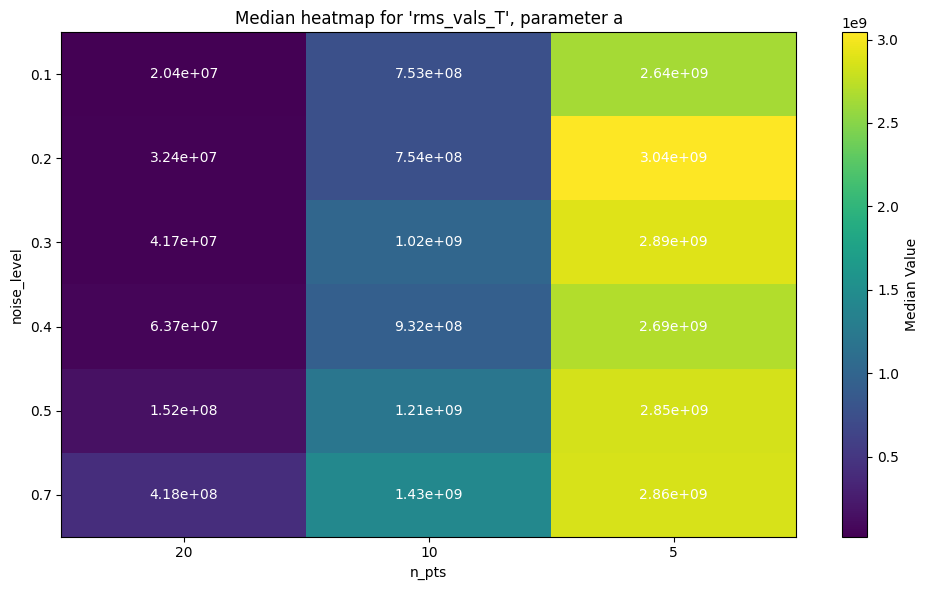

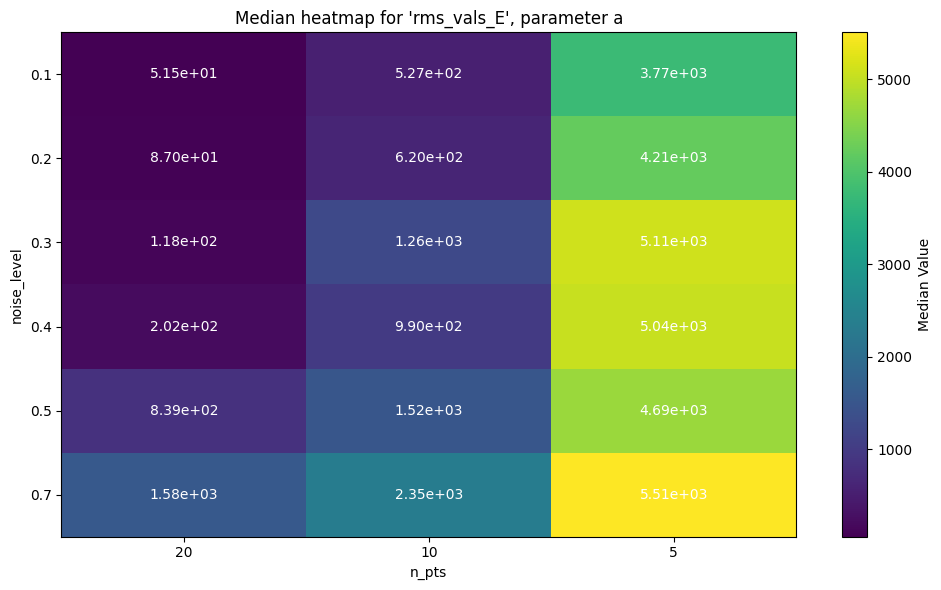

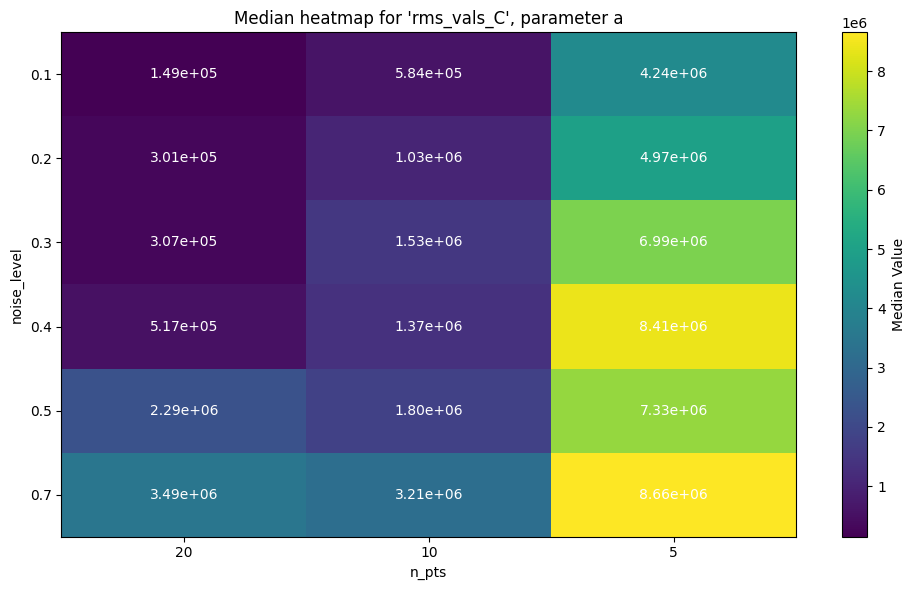

In [26]:
with open("results_a.txt", "r") as f:
    lines = [line.strip() for line in f.readlines()]
    results = [parse_line(line) for line in lines]
    agg = aggregate_dicts(results)

for key in results[0].keys():
    if (
        key not in ["param", "noise_level", "n_pts", "param_seed", "noise_seed"]
        and "_M" not in key
    ):
        plot_heatmap_from_aggregated(agg, key)

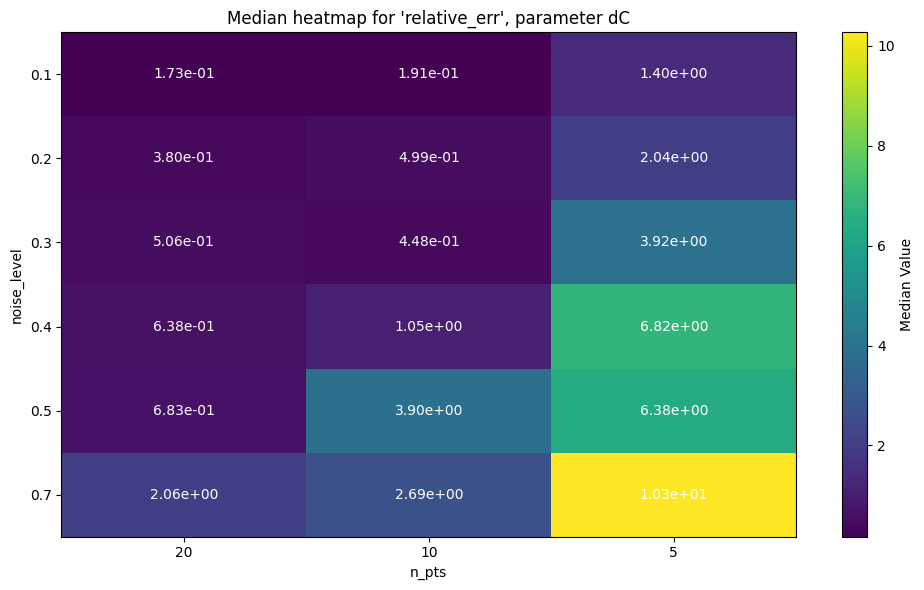

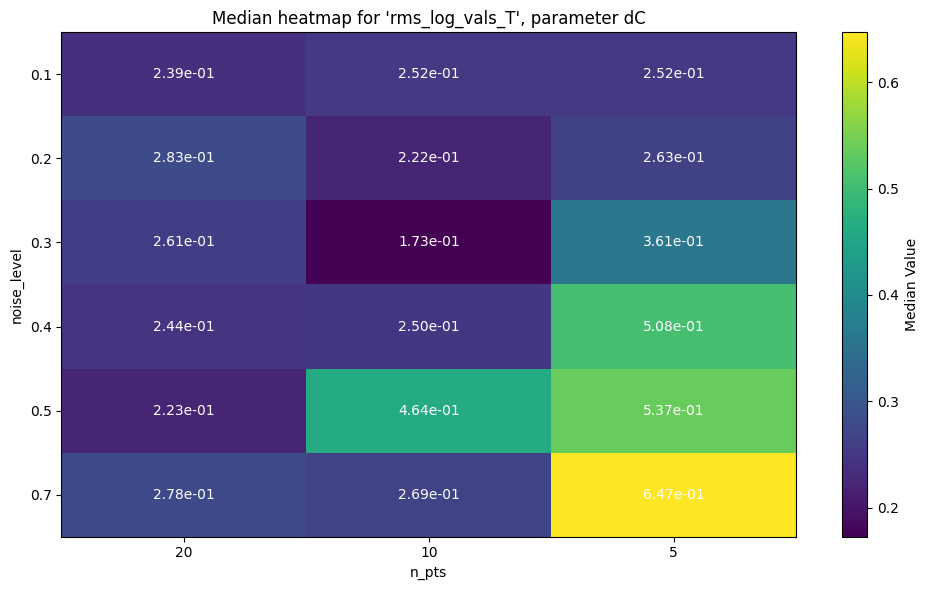

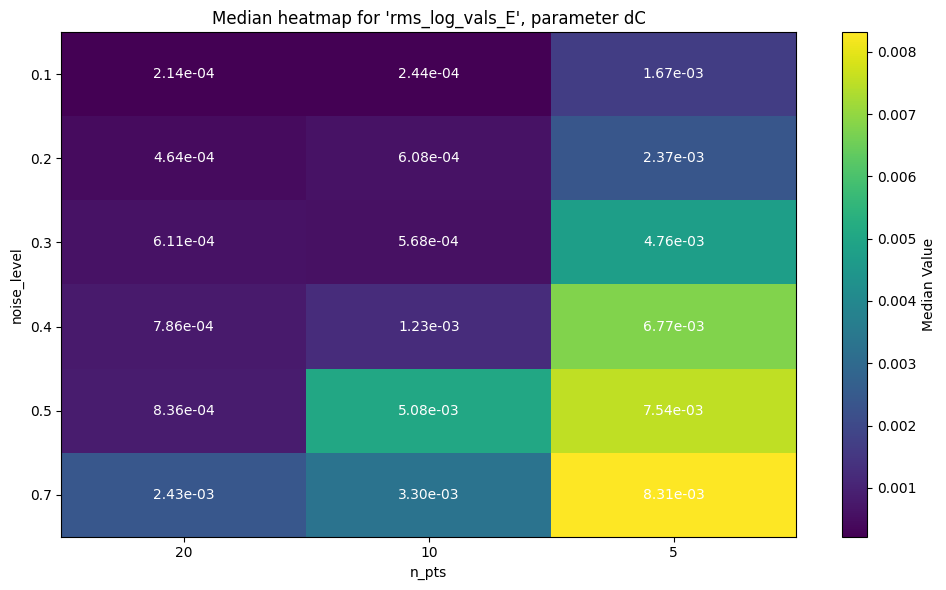

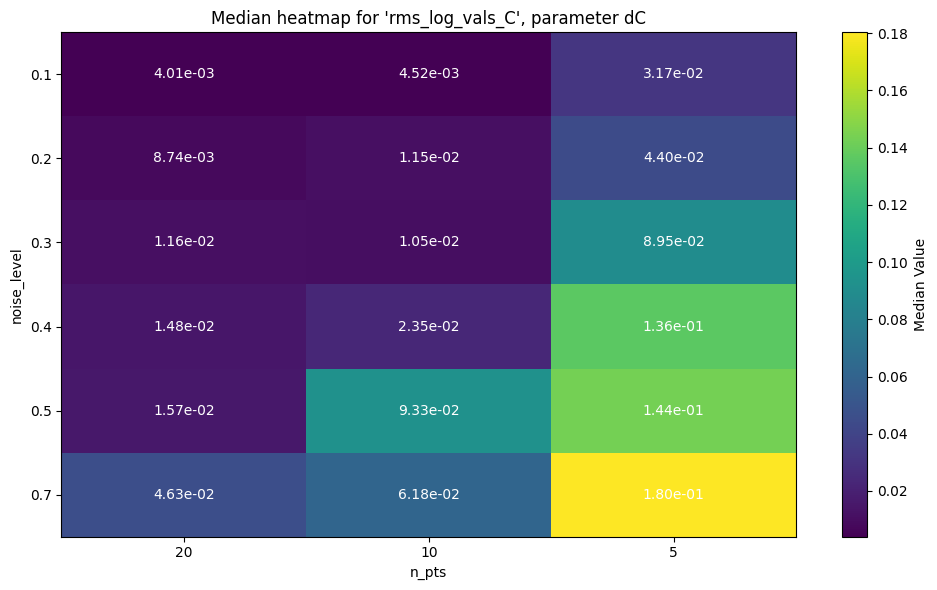

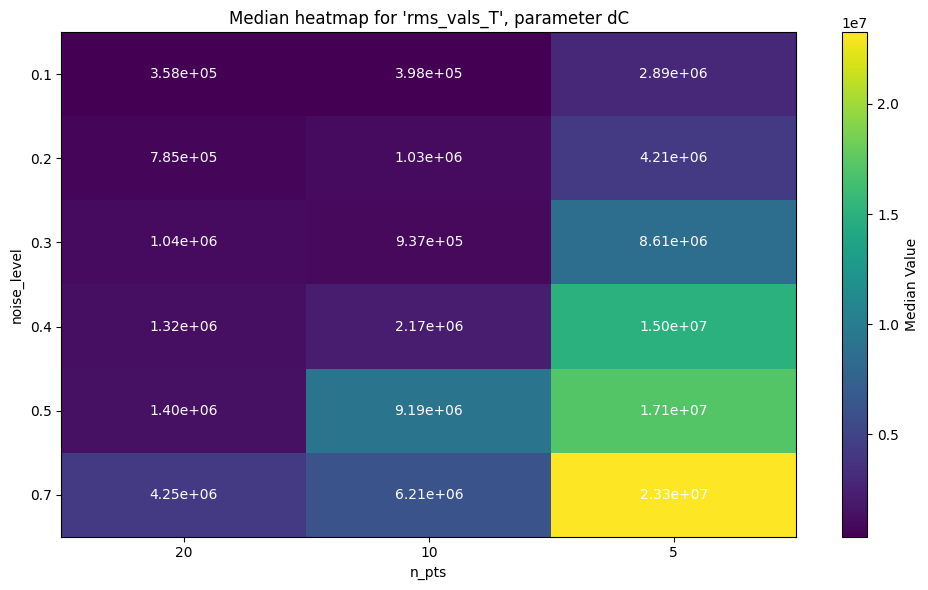

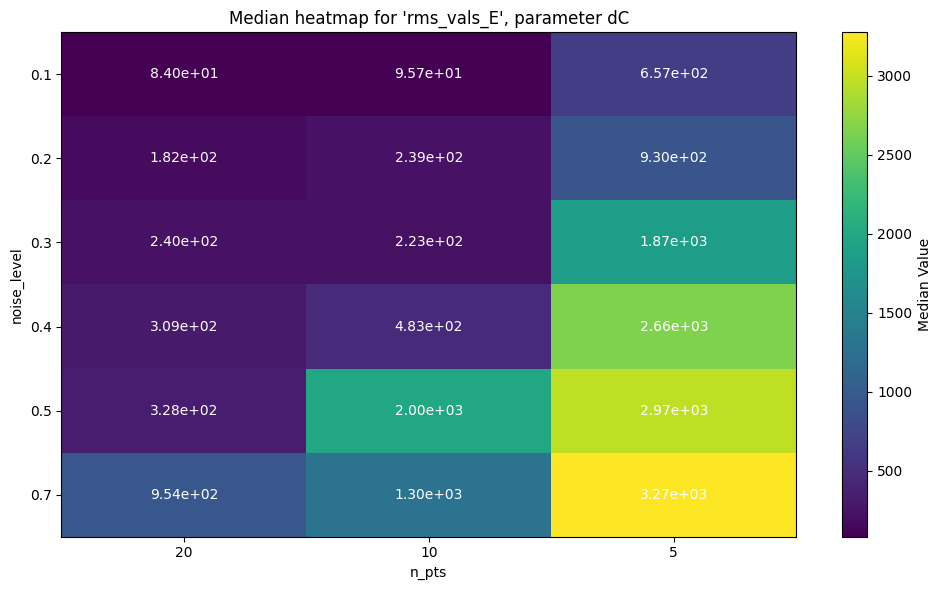

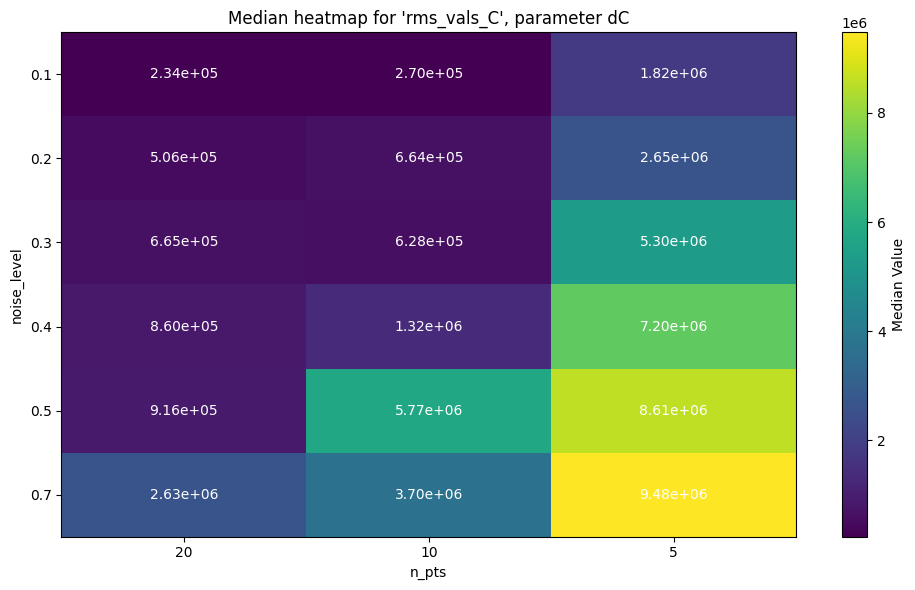

In [23]:
with open("results_dC.txt", "r") as f:
    lines = [line.strip() for line in f.readlines()]
    results = [parse_line(line) for line in lines]
    agg = aggregate_dicts(results)

for key in results[0].keys():
    if (
        key not in ["param", "noise_level", "n_pts", "param_seed", "noise_seed"]
        and "_M" not in key
    ):
        plot_heatmap_from_aggregated(agg, key)

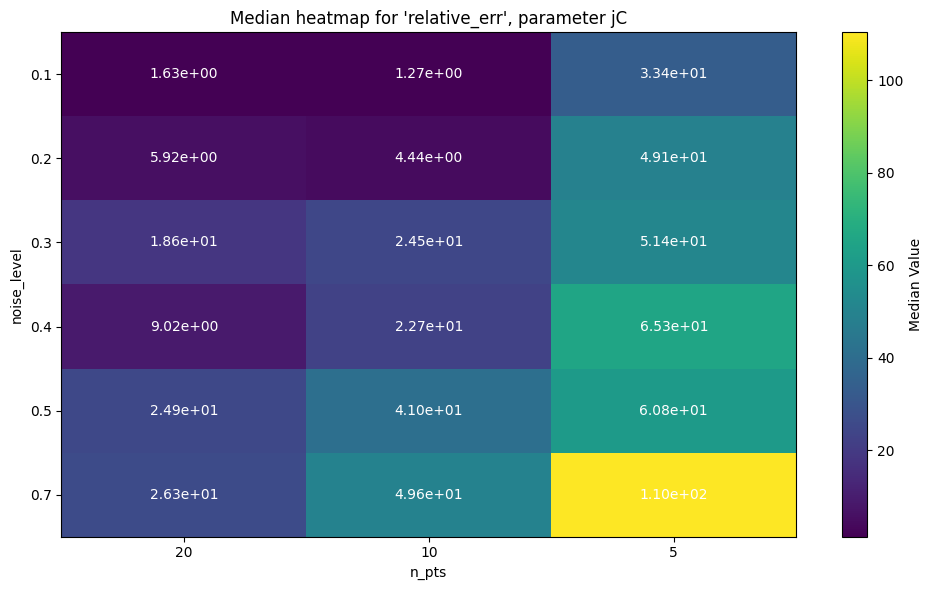

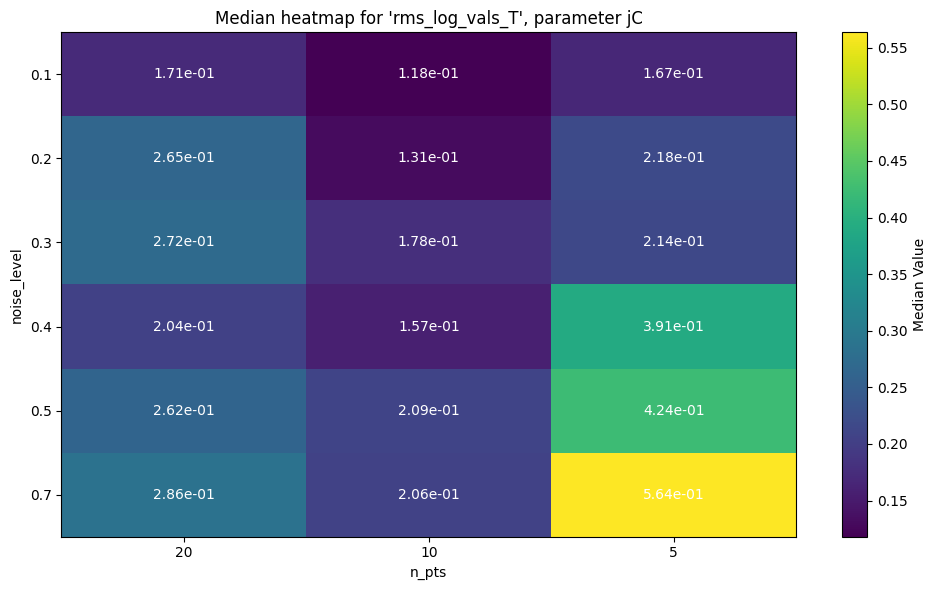

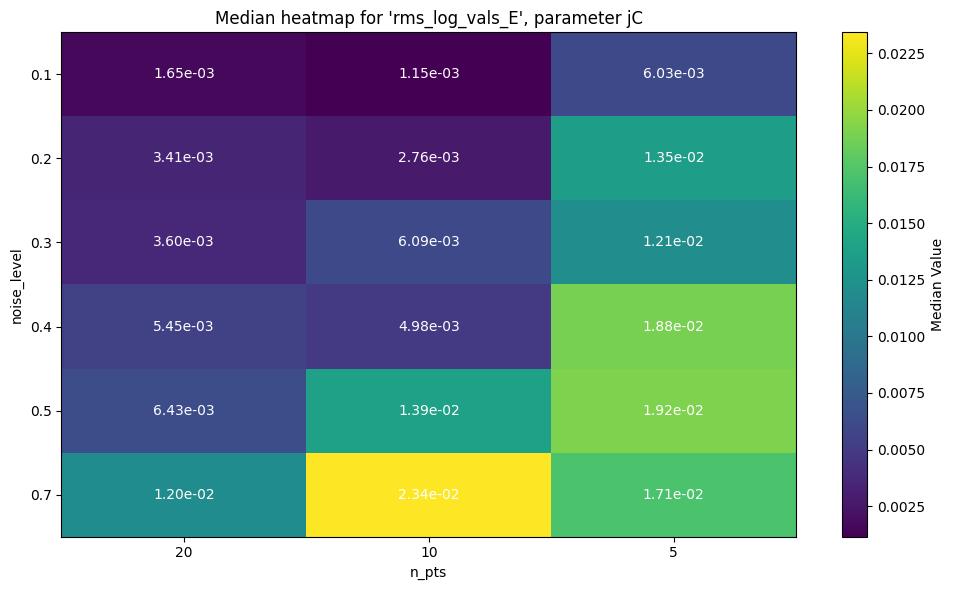

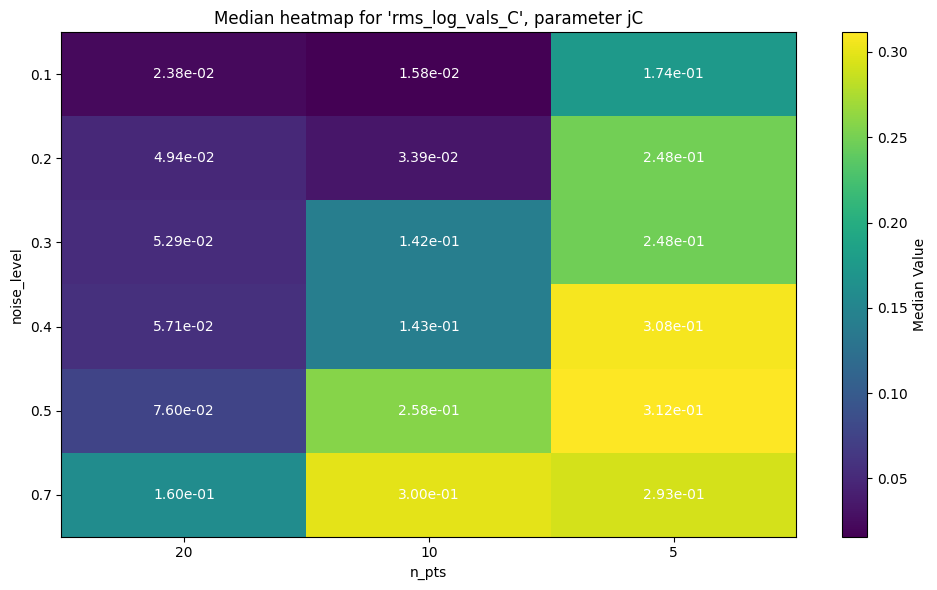

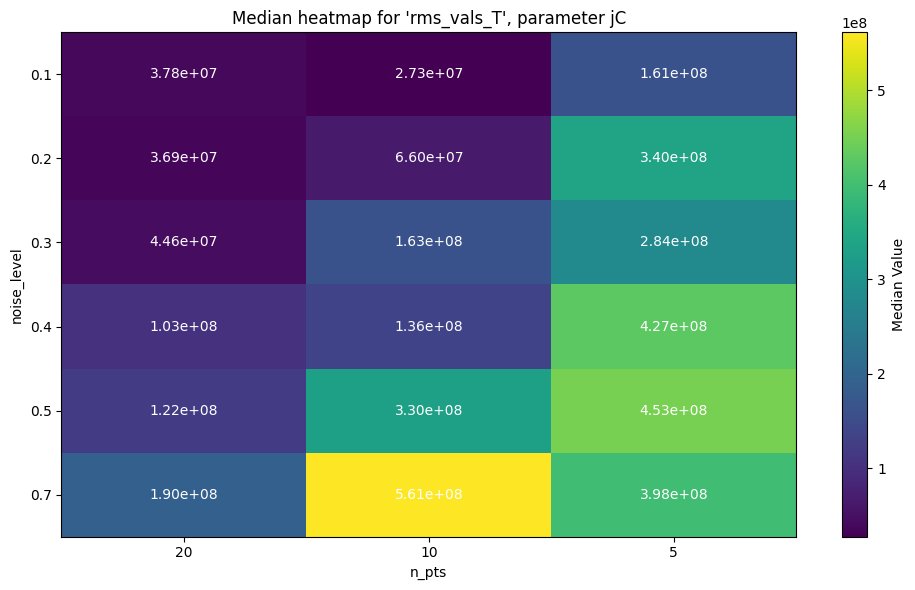

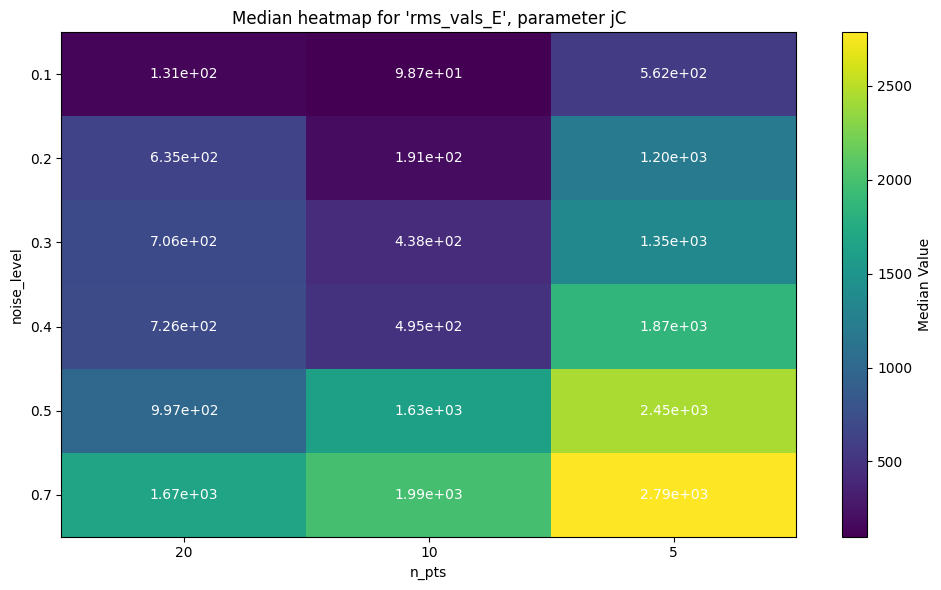

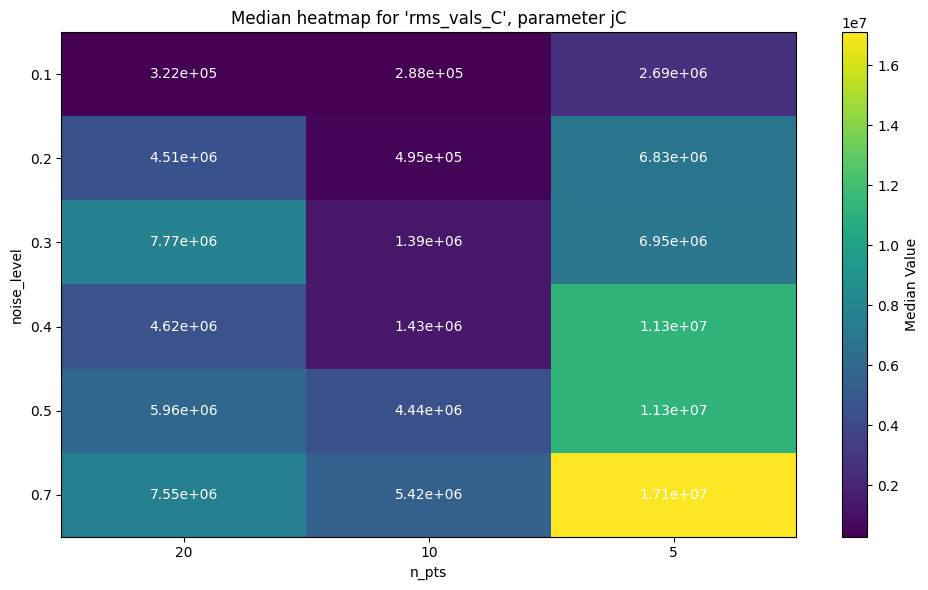

In [24]:
with open("results_jC.txt", "r") as f:
    lines = [line.strip() for line in f.readlines()]
    results = [parse_line(line) for line in lines]
    agg = aggregate_dicts(results)

for key in results[0].keys():
    if (
        key not in ["param", "noise_level", "n_pts", "param_seed", "noise_seed"]
        and "_M" not in key
    ):
        plot_heatmap_from_aggregated(agg, key)